#**Tarea 1: Configuracion del Entorno**

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import randint, norm, binom, uniform
import seaborn as sns

# Configuracion de estilo
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["font.size"] = 11

print("Entorno configurado correctamente")


Entorno configurado correctamente


#**Tarea 2: Variable Aleatoria Discreta - Lanzamiento de Dado**

In [ ]:
# Variable aleatoria: resultado de un dado
# X puede tomar valores: 1, 2, 3, 4, 5, 6

# Valores posibles
x_valores = np.array([1, 2, 3, 4, 5, 6])

# PMF: cada valor tiene probabilidad 1/6
pmf_dado = np.array([1/6, 1/6, 1/6, 1/6, 1/6, 1/6])

print("Valores de X:", x_valores)
print("PMF p(x):", pmf_dado)
print("Suma de probabilidades:", np.sum(pmf_dado))


Valores de X: [1 2 3 4 5 6]
PMF p(x): [0.16666667 0.16666667 0.16666667 0.16666667 0.16666667 0.16666667]
Suma de probabilidades: 0.9999999999999999


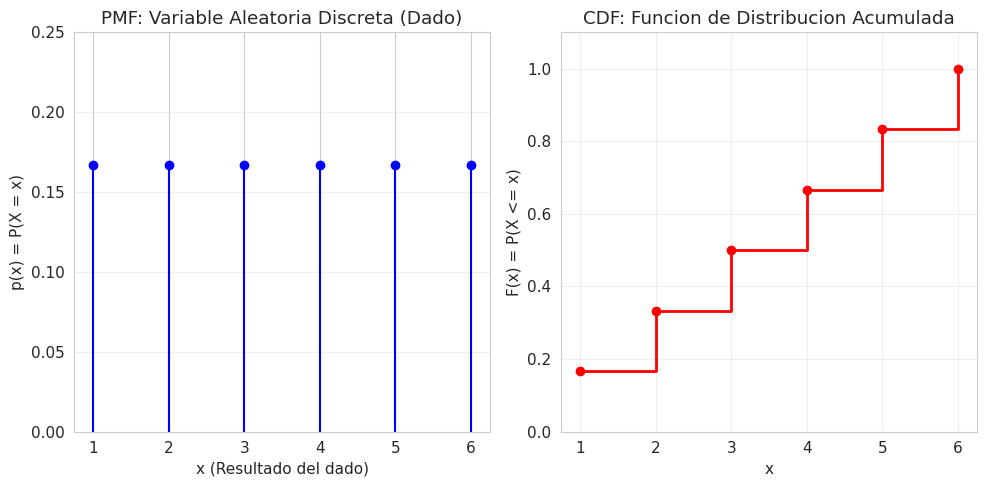

In [ ]:
# Visualizacion de la PMF
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.stem(x_valores, pmf_dado, basefmt=" ", linefmt='b-', markerfmt='bo')
plt.xlabel('x (Resultado del dado)')
plt.ylabel('p(x) = P(X = x)')
plt.title('PMF: Variable Aleatoria Discreta (Dado)')
plt.xticks(x_valores)
plt.ylim(0, 0.25)
plt.grid(axis='y', alpha=0.3)

# CDF
cdf_dado = np.cumsum(pmf_dado)
plt.subplot(1, 2, 2)
plt.step(x_valores, cdf_dado, where='post', color='red', linewidth=2)

plt.scatter(x_valores, cdf_dado, color='red', zorder=5)
plt.xlabel('x')
plt.ylabel('F(x) = P(X <= x)')
plt.title('CDF: Funcion de Distribucion Acumulada')
plt.xticks(x_valores)
plt.ylim(0, 1.1)
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()


In [ ]:
# a) P(X = 4)
prob_4 = pmf_dado[x_valores == 4][0]
print(f"P(X = 4) = {prob_4:.4f}")

# b) P(X <= 3) usando CDF
prob_menor_3 = cdf_dado[x_valores == 3][0]
print(f"P(X <= 3) = {prob_menor_3:.4f}")

# c) P(2 <= X <= 5)
prob_entre_2_5 = cdf_dado[x_valores == 5][0] - cdf_dado[x_valores == 1][0]
print(f"P(2 <= X <= 5) = {prob_entre_2_5:.4f}")


P(X = 4) = 0.1667
P(X <= 3) = 0.5000
P(2 <= X <= 5) = 0.6667


#**Tarea 3: Variable Aleatoria Continua - Distribucion Normal**

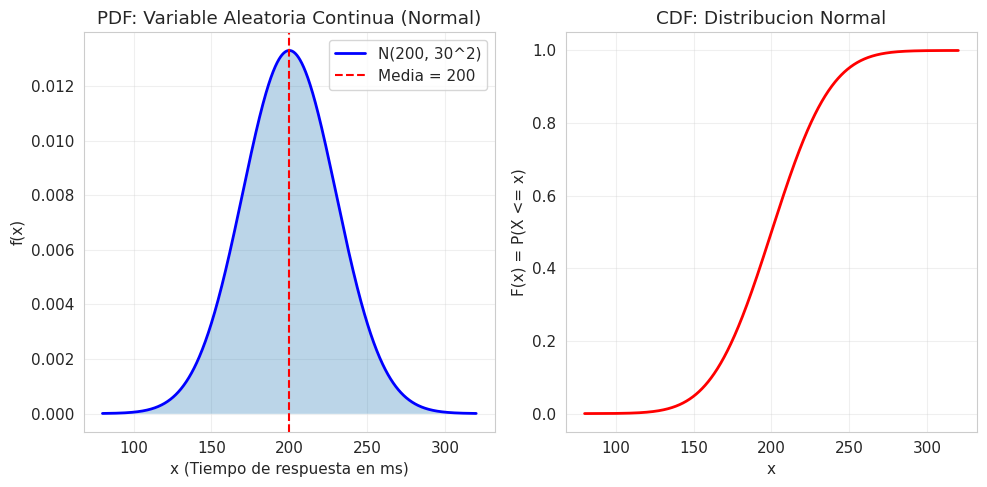

In [ ]:
# Parametros de la distribucion normal
mu = 200  # media
sigma = 30  # desviacion estandar

# Crear la distribucion
dist_normal = norm(loc=mu, scale=sigma)

# Rango de valores para graficar
x = np.linspace(mu - 4*sigma, mu + 4*sigma, 1000)

# PDF
pdf_normal = dist_normal.pdf(x)

# Visualizacion
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.plot(x, pdf_normal, 'b-', linewidth=2, label=f'N({mu}, {sigma}^2)')
plt.fill_between(x, pdf_normal, alpha=0.3)
plt.axvline(mu, color='red', linestyle='--', label=f'Media = {mu}')
plt.xlabel('x (Tiempo de respuesta en ms)')
plt.ylabel('f(x)')
plt.title('PDF: Variable Aleatoria Continua (Normal)')
plt.legend()
plt.grid(alpha=0.3)

# CDF
cdf_normal = dist_normal.cdf(x)
plt.subplot(1, 2, 2)
plt.plot(x, cdf_normal, 'r-', linewidth=2)
plt.xlabel('x')
plt.ylabel('F(x) = P(X <= x)')
plt.title('CDF: Distribucion Normal')
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()


In [ ]:
# a) P(X <= 180)
prob_menor_180 = dist_normal.cdf(180)
print(f"P(X <= 180) = {prob_menor_180:.4f} ({prob_menor_180*100:.2f}%)")

# b) P(X > 250)
prob_mayor_250 = 1 - dist_normal.cdf(250)
print(f"P(X > 250) = {prob_mayor_250:.4f} ({prob_mayor_250*100:.2f}%)")

# c) P(170 <= X <= 230)
prob_entre = dist_normal.cdf(230) - dist_normal.cdf(170)
print(f"P(170 <= X <= 230) = {prob_entre:.4f} ({prob_entre*100:.2f}%)")

# d) Percentil 95
p95 = dist_normal.ppf(0.95)
print(f"\nPercentil 95: {p95:.2f} ms")
print(f"El 95% de los tiempos de respuesta son menores a {p95:.2f} ms")


P(X <= 180) = 0.2525 (25.25%)
P(X > 250) = 0.0478 (4.78%)
P(170 <= X <= 230) = 0.6827 (68.27%)

Percentil 95: 249.35 ms
El 95% de los tiempos de respuesta son menores a 249.35 ms


#**Tarea 4: Comparacion Visual PMF vs PDF**

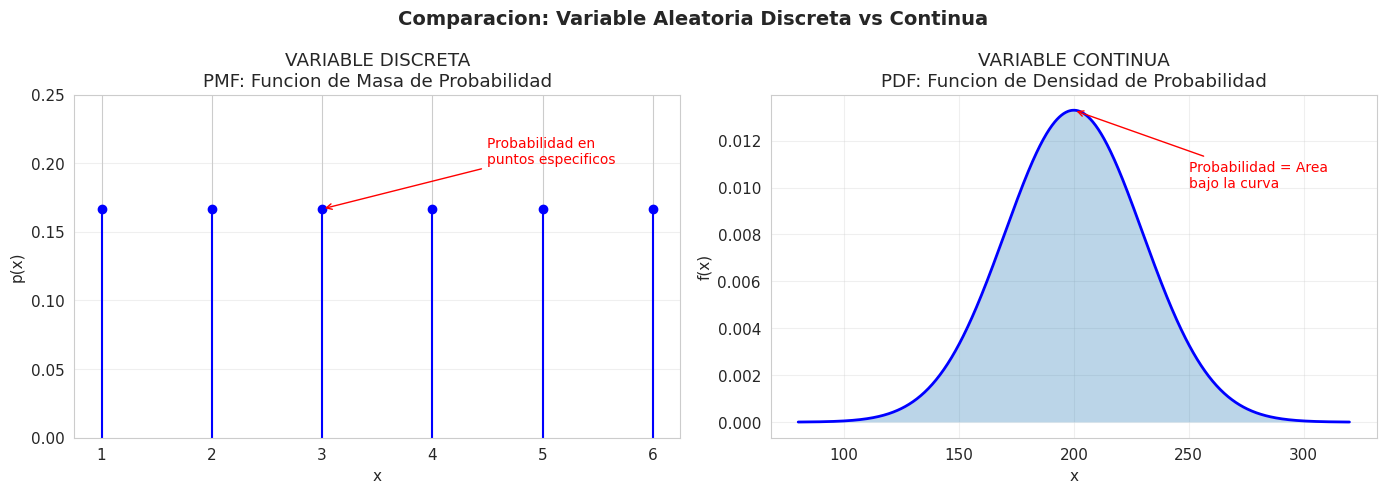

In [ ]:
# Comparacion PMF vs PDF
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Variable Discreta (Dado)
axes[0].stem(x_valores, pmf_dado, basefmt=" ", linefmt='b-', markerfmt='bo')
axes[0].set_xlabel('x')
axes[0].set_ylabel('p(x)')
axes[0].set_title('VARIABLE DISCRETA\nPMF: Funcion de Masa de Probabilidad')
axes[0].set_xticks(x_valores)
axes[0].set_ylim(0, 0.25)
axes[0].grid(axis='y', alpha=0.3)

# Anotaciones
axes[0].annotate('Probabilidad en\npuntos especificos', xy=(3, 1/6), xytext=(4.5, 0.2),
                 arrowprops=dict(arrowstyle='->', color='red'),
                 fontsize=10, color='red')

# Variable Continua (Normal)
axes[1].plot(x, pdf_normal, 'b-', linewidth=2)
axes[1].fill_between(x, pdf_normal, alpha=0.3)
axes[1].set_xlabel('x')
axes[1].set_ylabel('f(x)')
axes[1].set_title('VARIABLE CONTINUA\nPDF: Funcion de Densidad de Probabilidad')
axes[1].grid(alpha=0.3)

# Anotaciones
axes[1].annotate('Probabilidad = Area\nbajo la curva', xy=(200, norm.pdf(200, 200, 30)), xytext=(250, 0.01),
                 arrowprops=dict(arrowstyle='->', color='red'),
                 fontsize=10, color='red')

plt.suptitle('Comparacion: Variable Aleatoria Discreta vs Continua', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


#**Tarea 5: Aplicacion - Variables Aleatorias en la UNL**

In [ ]:
# Plantilla para registro de variables
variables_unl = [
    {
        'nombre'              : 'Número de libros prestados por hora',
        'ubicacion'           : 'Biblioteca',
        'tipo'                : 'Discreta',
        'valores_posibles'    : '0, 1, 2, 3, ... (enteros no negativos)',
        'distribucion_esperada': 'Poisson — conteo de eventos en intervalo fijo'
    },
    {
        'nombre'              : 'Tiempo de espera en la fila para pedir',
        'ubicacion'           : 'Cafetería',
        'tipo'                : 'Continua',
        'valores_posibles'    : '[0, +∞) minutos',
        'distribucion_esperada': 'Exponencial — tiempos entre llegadas de clientes'
    },
    {
        'nombre'              : 'Tiempo de uso de una computadora',
        'ubicacion'           : 'Laboratorios',
        'tipo'                : 'Continua',
        'valores_posibles'    : '[0, +∞) minutos',
        'distribucion_esperada': 'Normal — tiempos agrupados alrededor de una media'
    },
    {
        'nombre'              : 'Número de vehículos estacionados a las 9h00',
        'ubicacion'           : 'Estacionamiento',
        'tipo'                : 'Discreta',
        'valores_posibles'    : '0, 1, 2, ..., capacidad máxima',
        'distribucion_esperada': 'Binomial — cada espacio ocupado o libre con prob. p'
    },
    {
        'nombre'              : 'Número de estudiantes que asisten a clase',
        'ubicacion'           : 'Aulas de clase',
        'tipo'                : 'Discreta',
        'valores_posibles'    : '0, 1, 2, ..., N (total matriculados)',
        'distribucion_esperada': 'Binomial — cada estudiante asiste o no con prob. p'
    },
]

# Mostrar tabla formateada
import pandas as pd
df = pd.DataFrame(variables_unl)
print(df.to_string(index=False))


                                     nombre       ubicacion     tipo                       valores_posibles                               distribucion_esperada
        Número de libros prestados por hora      Biblioteca Discreta 0, 1, 2, 3, ... (enteros no negativos)       Poisson — conteo de eventos en intervalo fijo
     Tiempo de espera en la fila para pedir       Cafetería Continua                        [0, +∞) minutos    Exponencial — tiempos entre llegadas de clientes
           Tiempo de uso de una computadora    Laboratorios Continua                        [0, +∞) minutos   Normal — tiempos agrupados alrededor de una media
Número de vehículos estacionados a las 9h00 Estacionamiento Discreta         0, 1, 2, ..., capacidad máxima Binomial — cada espacio ocupado o libre con prob. p
  Número de estudiantes que asisten a clase  Aulas de clase Discreta   0, 1, 2, ..., N (total matriculados)  Binomial — cada estudiante asiste o no con prob. p


#**Modificación del codigo de la Tarea 3**


#Variable escogida: Distribución Binomial

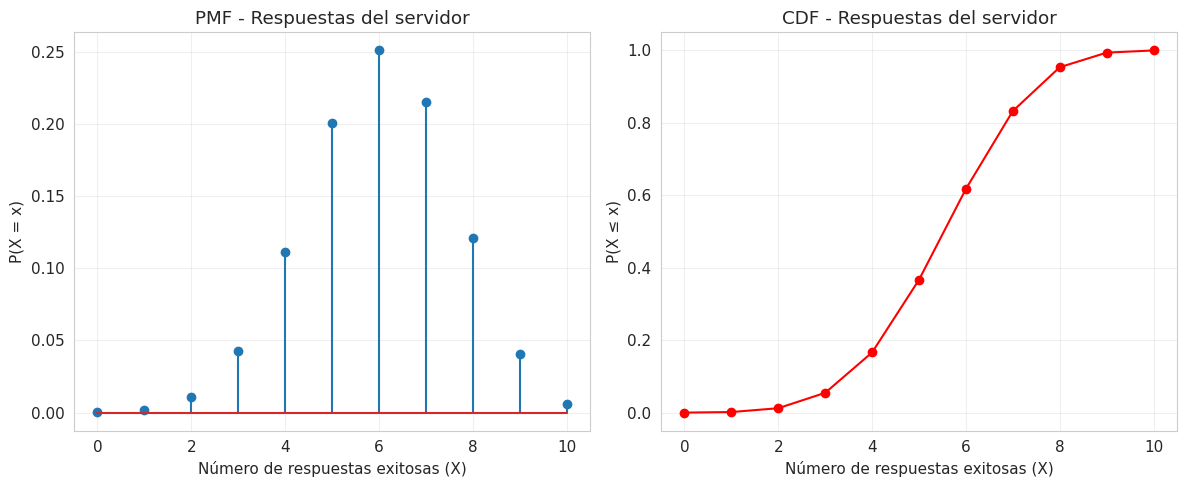

In [5]:

# ---------------------------------------------------
# 1. Parámetros del problema
# ---------------------------------------------------
n = 10   # número de solicitudes al servidor
p = 0.6  # probabilidad de que el servidor responda correctamente

dist = binom(n, p)

# ---------------------------------------------------
# 2. Valores posibles de X
# ---------------------------------------------------
x = np.arange(0, n + 1)

# ---------------------------------------------------
# 3. PMF (Probabilidad de masa)
# ---------------------------------------------------
pmf = dist.pmf(x)

# ---------------------------------------------------
# 4. CDF (Probabilidad acumulada)
# ---------------------------------------------------
cdf = dist.cdf(x)

# ---------------------------------------------------
# 5. Gráficas PMF y CDF
# ---------------------------------------------------
plt.figure(figsize=(12, 5))

# PMF
plt.subplot(1, 2, 1)
plt.stem(x, pmf)
plt.xlabel("Número de respuestas exitosas (X)")
plt.ylabel("P(X = x)")
plt.title("PMF - Respuestas del servidor")
plt.grid(alpha=0.3)

# CDF
plt.subplot(1, 2, 2)
plt.plot(x, cdf, 'r-o')
plt.xlabel("Número de respuestas exitosas (X)")
plt.ylabel("P(X ≤ x)")
plt.title("CDF - Respuestas del servidor")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [6]:
# ---------------------------------------------------
# Probabilidades especificas
# ---------------------------------------------------
p1 = dist.cdf(5)
print(f"P(X <= 5) = {p1:.4f} ({p1*100:.2f}%)")

# ---------------------------------------------------
# b) P(X > 7) -> más de 7 respuestas correctas
# ---------------------------------------------------
p2 = 1 - dist.cdf(7)
print(f"P(X > 7) = {p2:.4f} ({p2*100:.2f}%)")

# ---------------------------------------------------
# c) P(X = 6) -> exactamente 6 respuestas correctas
# ---------------------------------------------------
p3 = dist.pmf(6)
print(f"P(X = 6) = {p3:.4f} ({p3*100:.2f}%)")

P(X <= 5) = 0.3669 (36.69%)
P(X > 7) = 0.1673 (16.73%)
P(X = 6) = 0.2508 (25.08%)
